# 13 -- Macro regime overlay

**Цель:** сократить exposure в stress periods (как 2022 шок), снизить MaxDD, повысить risk-adjusted return.

**Stress signals:**
- **RVI** (Russian VIX) > 90th percentile rolling 252 days
- **Key rate change** > 200 bps за неделю
- **IMOEX drawdown** > 10% за 5 дней
- **OFZ slope** flat/inverted (proxy: |slope| < some threshold)

**Подходы:**
1. **Rules-based** — composite stress index из 4 сигналов, threshold-based regime
2. **Markov-Switching** (Hamilton 1989) — ML вариант регим-detection

**Strategy overlay:**
- В normal regime: full exposure (V11e baseline)
- В stress regime: cut exposure (50% или 0%)

**Литература:**
- Hamilton (Econometrica 1989) — Markov switching regression
- Ang, Bekaert (RFS 2002) — regime switching в asset returns
- Cooper-Gulen-Schill (JoF 2008) — momentum & macro state

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
np.random.seed(42)
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

macro = pd.read_csv(sl.DATA_DIR / 'macro.csv', parse_dates=['date'])
macro = macro.sort_values('date').reset_index(drop=True)
print(f'macro: {macro.shape}, range {macro["date"].min().date()}..{macro["date"].max().date()}')
print(macro.columns.tolist())

macro: (2646, 8), range 2019-01-01..2026-03-30
['date', 'key_rate', 'usdrub', 'imoex_close', 'imoex_return', 'imoex_realized_vol', 'rvi', 'oil_brent']


## Часть 2. Compute stress signals

In [2]:
# 1. RVI rolling percentile
macro['rvi_p90_252d'] = macro['rvi'].rolling(252, min_periods=60).quantile(0.90)
macro['stress_rvi'] = (macro['rvi'] > macro['rvi_p90_252d']).astype(int)

# 2. Key rate weekly change
macro['key_rate_delta_5d'] = macro['key_rate'].diff(5)
macro['stress_kr'] = (macro['key_rate_delta_5d'].abs() > 2.0).astype(int)  # 200 bps

# 3. IMOEX drawdown 5d
macro['imoex_5d_return'] = macro['imoex_close'].pct_change(5)
macro['stress_imoex'] = (macro['imoex_5d_return'] < -0.10).astype(int)

# 4. RVI absolute high (>50)
macro['stress_rvi_abs'] = (macro['rvi'] > 50).astype(int)

# Composite stress index
macro['stress_index'] = (
    macro['stress_rvi'].fillna(0) +
    macro['stress_kr'].fillna(0) +
    macro['stress_imoex'].fillna(0) +
    macro['stress_rvi_abs'].fillna(0)
)

# Regime: stress if any 2 of 4 signals active
macro['regime'] = np.where(macro['stress_index'] >= 2, 'stress', 'normal')

print('Stress regime distribution (full period):')
print(macro['regime'].value_counts(normalize=True).round(3))
print()
print('Stress periods:')
stress = macro[macro['regime'] == 'stress'].copy()
stress['gap'] = (stress['date'].diff() > pd.Timedelta(days=7)).cumsum()
groups = stress.groupby('gap')['date'].agg(['min', 'max', 'count'])
print(groups[groups['count'] > 5].to_string())

Stress regime distribution (full period):
regime
normal    0.948
stress    0.052
Name: proportion, dtype: float64

Stress periods:
           min        max  count
gap                             
1   2020-03-10 2020-04-05     27
3   2022-01-18 2022-01-30     13
4   2022-02-14 2022-03-28     42
9   2024-11-25 2024-12-01      7
12  2025-04-07 2025-04-27     21


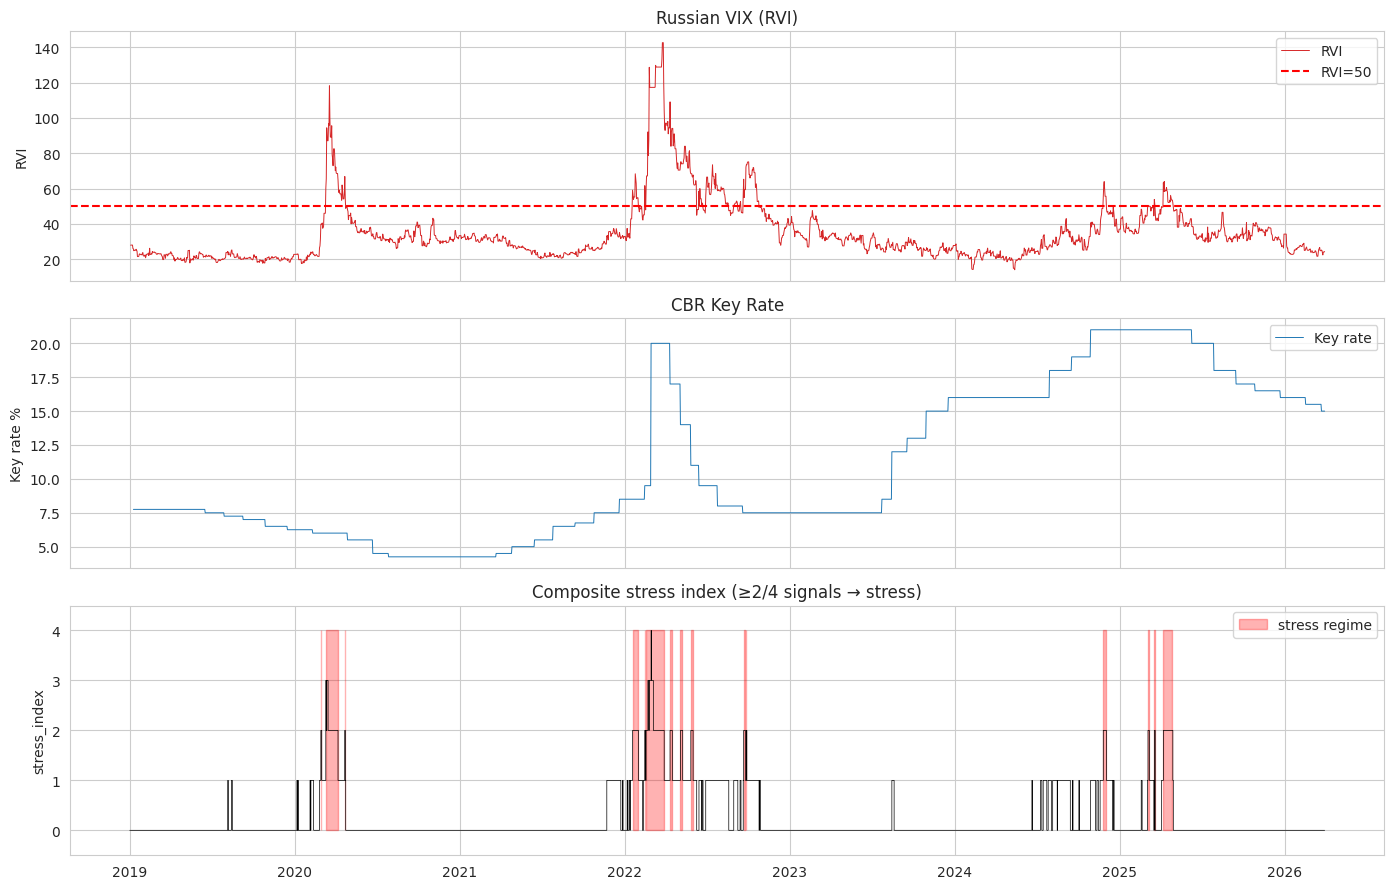

In [3]:
# График: stress index over time
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(macro['date'], macro['rvi'], color='tab:red', label='RVI', linewidth=0.7)
axes[0].axhline(50, color='red', linestyle='--', label='RVI=50')
axes[0].set_ylabel('RVI')
axes[0].legend()
axes[0].set_title('Russian VIX (RVI)')

axes[1].plot(macro['date'], macro['key_rate'], color='tab:blue', label='Key rate', linewidth=0.7)
axes[1].set_ylabel('Key rate %')
axes[1].legend()
axes[1].set_title('CBR Key Rate')

axes[2].plot(macro['date'], macro['stress_index'], color='black', drawstyle='steps-post', linewidth=0.5)
stress_mask = macro['regime'] == 'stress'
axes[2].fill_between(macro['date'], 0, 4, where=stress_mask, color='red', alpha=0.3, label='stress regime')
axes[2].set_ylabel('stress_index')
axes[2].set_title('Composite stress index (≥2/4 signals → stress)')
axes[2].set_ylim(-0.5, 4.5)
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '13_stress_signals.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 3. Apply overlay to V11e

In [4]:
# Загружаем V11e returns
rets_all = pd.read_csv(sl.DATA_DIR / 'nb11_returns.csv', parse_dates=['date'])
v11e = rets_all[rets_all['variant'] == 'V11e avg_z + Q + zw (combo W2)'].copy()

# Merge regime
v11e = v11e.merge(macro[['date', 'regime', 'stress_index']], on='date', how='left')
v11e['regime'] = v11e['regime'].fillna('normal')
print(f'V11e dates: {len(v11e)}')
print(f'  in normal regime: {(v11e["regime"] == "normal").sum()}')
print(f'  in stress regime: {(v11e["regime"] == "stress").sum()}')

# Variants: 
# V13a: cut exposure to 0% in stress
# V13b: cut exposure to 50% in stress
# V13c: cut to 0% if stress_index >= 3 (more conservative entry to stress)

def apply_overlay(rets, regime_col='regime', scale_normal=1.0, scale_stress=0.0,
                  variant_name=''):
    out = rets.copy()
    out['scale'] = np.where(out[regime_col] == 'stress', scale_stress, scale_normal)
    out['return_overlay'] = out['return'] * out['scale']
    return pd.DataFrame({
        'date': out['date'],
        'return': out['return_overlay'],
        'n_positions': out['n_positions'],
    })

v11e_clean = pd.DataFrame({
    'date': v11e['date'], 'return': v11e['return'], 'n_positions': v11e['n_positions']
})

rets_v13a = apply_overlay(v11e, scale_stress=0.0, variant_name='V13a cut to 0% in stress')
rets_v13b = apply_overlay(v11e, scale_stress=0.5, variant_name='V13b 50% in stress')

# V13c: stress only if stress_index >= 3 (very strict)
v11e_strict = v11e.copy()
v11e_strict['regime_strict'] = np.where(v11e_strict['stress_index'].fillna(0) >= 3, 'stress', 'normal')
rets_v13c = apply_overlay(v11e_strict, regime_col='regime_strict', scale_stress=0.0,
                           variant_name='V13c strict (idx>=3) cut 0%')

all_rets = {
    'BASELINE V11e (no overlay)': v11e_clean,
    'V13a cut 0% in stress': rets_v13a,
    'V13b 50% in stress': rets_v13b,
    'V13c strict cut 0%': rets_v13c,
}

all_metrics = []
for name, r in all_rets.items():
    m = sl.calc_metrics(r, name=name)
    all_metrics.append(m)
    print(f'{name:35s}: Sharpe={m["Sharpe"]:.3f}, CAGR={m["CAGR"]*100:.2f}%, '
          f'MaxDD={m["MaxDD"]*100:.2f}%, profit={m["profit_RUB"]:>11,.0f}')

metrics_df = pd.DataFrame(all_metrics)
print()
print(metrics_df[['name', 'Sharpe', 'CAGR', 'MaxDD', 'profit_RUB']].round(4))

V11e dates: 1118
  in normal regime: 1061
  in stress regime: 57
BASELINE V11e (no overlay)         : Sharpe=1.202, CAGR=7.47%, MaxDD=-14.02%, profit=  3,826,103
V13a cut 0% in stress              : Sharpe=2.323, CAGR=9.93%, MaxDD=-5.12%, profit=  5,312,148
V13b 50% in stress                 : Sharpe=1.799, CAGR=8.72%, MaxDD=-7.79%, profit=  4,568,651
V13c strict cut 0%                 : Sharpe=2.153, CAGR=9.85%, MaxDD=-6.17%, profit=  5,258,651

                         name  Sharpe    CAGR   MaxDD    profit_RUB
0  BASELINE V11e (no overlay)  1.2015  0.0747 -0.1402  3.826103e+06
1       V13a cut 0% in stress  2.3226  0.0993 -0.0512  5.312148e+06
2          V13b 50% in stress  1.7986  0.0872 -0.0779  4.568651e+06
3          V13c strict cut 0%  2.1532  0.0985 -0.0617  5.258651e+06


## Часть 4. Markov-Switching regime detection (ML approach)

In [5]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# Используем дневной RUCBTRNS return и моделируем 2 регима со switching variance
bench = sl.load_benchmarks()
bench = bench.sort_values('date').reset_index(drop=True)

# Подготовка: RUCBTRNS return, drop NaN
y = bench['rucbtrns_ret'].dropna().values
y_dates = bench['date'][bench['rucbtrns_ret'].notna()].values
print(f'MS-AR(0) на rucbtrns_ret, n={len(y)}')

# Fit 2-regime model (constant mean, switching variance)
ms_model = MarkovRegression(y, k_regimes=2, switching_variance=True, trend='c')
ms_res = ms_model.fit(maxiter=200)
print(ms_res.summary())

# Get smoothed regime probabilities
# statsmodels returns DataFrame: columns = regime indices, rows = time
smoothed_probs = ms_res.smoothed_marginal_probabilities
if hasattr(smoothed_probs, 'columns'):
    # DataFrame: columns 0, 1
    prob_reg0 = smoothed_probs.iloc[:, 0].values
    prob_reg1 = smoothed_probs.iloc[:, 1].values
else:
    # ndarray shape (n, k)
    prob_reg0 = smoothed_probs[:, 0]
    prob_reg1 = smoothed_probs[:, 1]

# Variance parameters: keys can vary by statsmodels version
params = ms_res.params
if hasattr(params, 'index'):
    var_keys = [k for k in params.index if 'sigma2' in k or 'variance' in k.lower()]
    regime0_var = float(params[var_keys[0]]) if len(var_keys) >= 1 else float('nan')
    regime1_var = float(params[var_keys[1]]) if len(var_keys) >= 2 else float('nan')
else:
    # numpy array — last two params are typically variances
    regime0_var = float(params[-2])
    regime1_var = float(params[-1])
print(f'Params: {params}')
stress_regime = 1 if regime1_var > regime0_var else 0
print(f'Regime 0 variance: {regime0_var:.6f}')
print(f'Regime 1 variance: {regime1_var:.6f}')
print(f'Stress regime is: {stress_regime}')

# Build MS regime indicator
p_stress = prob_reg1 if stress_regime == 1 else prob_reg0
ms_df = pd.DataFrame({
    'date': y_dates,
    'p_stress_ms': p_stress,
})
ms_df['regime_ms'] = np.where(ms_df['p_stress_ms'] > 0.5, 'stress', 'normal')
print(f'\nMS regime distribution:')
print(ms_df['regime_ms'].value_counts(normalize=True).round(3))

MS-AR(0) на rucbtrns_ret, n=1309
                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                 1309
Model:               MarkovRegression   Log Likelihood                6686.903
Date:                Tue, 12 May 2026   AIC                         -13361.807
Time:                        16:31:48   BIC                         -13330.744
Sample:                             0   HQIC                        -13350.156
                               - 1309                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003   3.36e-05      8.489      0.000       0.000       0.000
sigma2      1.031e-

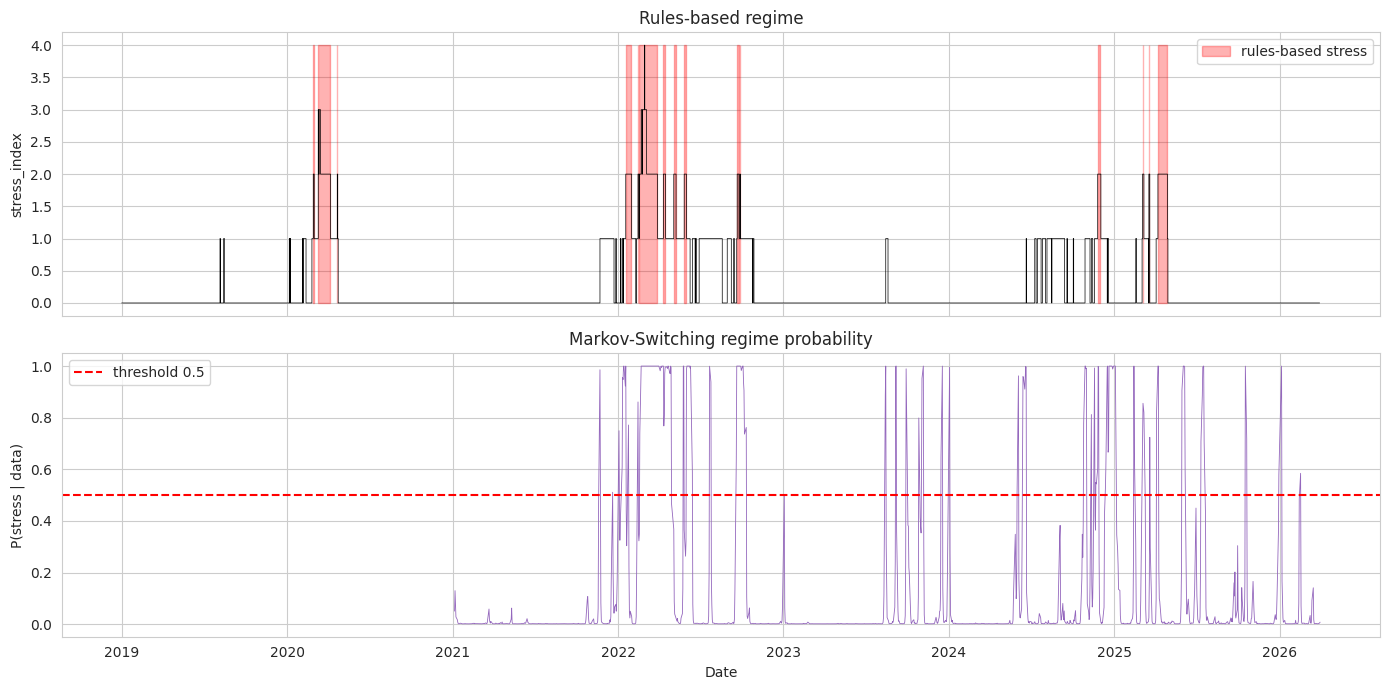

In [6]:
# Visualize: rules-based vs MS regime
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(macro['date'], macro['stress_index'], color='black', drawstyle='steps-post', linewidth=0.5)
mask = macro['regime'] == 'stress'
axes[0].fill_between(macro['date'], 0, 4, where=mask, color='red', alpha=0.3, label='rules-based stress')
axes[0].set_ylabel('stress_index')
axes[0].set_title('Rules-based regime')
axes[0].legend()

axes[1].plot(ms_df['date'], ms_df['p_stress_ms'], color='tab:purple', linewidth=0.6)
axes[1].axhline(0.5, color='red', linestyle='--', label='threshold 0.5')
axes[1].set_ylabel('P(stress | data)')
axes[1].set_title('Markov-Switching regime probability')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '13_ms_regime.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# V13d: Markov-Switching overlay
v11e_ms = v11e[['date', 'return', 'n_positions']].copy().merge(
    ms_df[['date', 'regime_ms']], on='date', how='left')
v11e_ms['regime_ms'] = v11e_ms['regime_ms'].fillna('normal')
rets_v13d = apply_overlay(v11e_ms, regime_col='regime_ms', scale_stress=0.0,
                           variant_name='V13d MS cut 0%')
rets_v13e = apply_overlay(v11e_ms, regime_col='regime_ms', scale_stress=0.5,
                           variant_name='V13e MS 50%')

for name, r in [('V13d MS cut 0%', rets_v13d), ('V13e MS 50%', rets_v13e)]:
    m = sl.calc_metrics(r, name=name)
    all_rets[name] = r
    all_metrics.append(m)
    print(f'{name:35s}: Sharpe={m["Sharpe"]:.3f}, CAGR={m["CAGR"]*100:.2f}%, '
          f'MaxDD={m["MaxDD"]*100:.2f}%, profit={m["profit_RUB"]:>11,.0f}')

V13d MS cut 0%                     : Sharpe=2.407, CAGR=6.80%, MaxDD=-2.57%, profit=  3,443,041
V13e MS 50%                        : Sharpe=1.801, CAGR=7.18%, MaxDD=-6.80%, profit=  3,657,966


## Часть 5. Alpha vs ETFs (Main only)

In [8]:
etfs = pd.read_csv(sl.DATA_DIR / 'etfs.csv', parse_dates=['date'])
etfs_with_rucb = etfs.merge(sl.load_benchmarks()[['date', 'rucbtrns_ret']], on='date', how='left')

alpha_rows = []
for name, rets in all_rets.items():
    main = rets[rets['date'] <= sl.MAIN_END]
    for bench_col, bench_name in [('rucbtrns_ret', 'RUCBTRNS'), ('oblg_ret', 'OBLG'),
                                    ('sbrb_ret', 'SBRB'), ('tbru_ret', 'TBRU')]:
        try:
            r = sl.compare_to_benchmark(main, etfs_with_rucb, bench_col=bench_col, name=name)
            r['benchmark'] = bench_name
            alpha_rows.append(r)
        except Exception as e:
            pass

alpha_df = pd.DataFrame(alpha_rows)
print('Alpha vs benchmarks (Main period):')
for bn in ['OBLG', 'SBRB', 'TBRU']:
    sub = alpha_df[alpha_df['benchmark'] == bn]
    print(f'\n=== vs {bn} ===')
    print(sub[['name', 'alpha_annual', 'alpha_t_stat', 'IR', 'sharpe_diff']].round(4).to_string(index=False))

Alpha vs benchmarks (Main period):

=== vs OBLG ===
                      name  alpha_annual  alpha_t_stat      IR  sharpe_diff
BASELINE V11e (no overlay)        0.0203        1.1360 -0.2042       0.0714
     V13a cut 0% in stress        0.0855        3.3224  0.1625       1.1980
        V13b 50% in stress        0.0529        2.8392  0.0228       0.6716
        V13c strict cut 0%        0.0823        2.9051  0.1547       1.0276
            V13d MS cut 0%        0.0647        4.2826 -0.2276       1.2874
               V13e MS 50%        0.0425        3.0903 -0.2363       0.6759

=== vs SBRB ===
                      name  alpha_annual  alpha_t_stat      IR  sharpe_diff
BASELINE V11e (no overlay)        0.0234        0.8345 -0.4228       0.0186
     V13a cut 0% in stress        0.0847        3.4301 -0.0472       1.1391
        V13b 50% in stress        0.0540        2.5135 -0.2118       0.6142
        V13c strict cut 0%        0.0818        3.0431 -0.0552       0.9697
            V13d MS

## Часть 6. Sub-period analysis

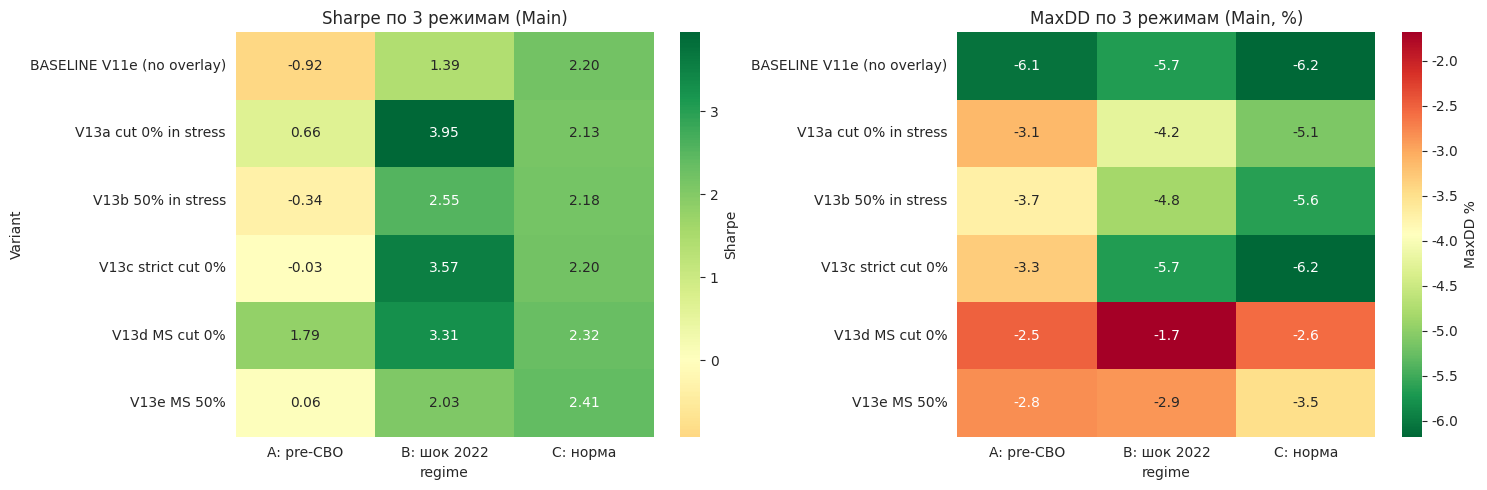

In [9]:
sub_rows = []
for name, rets in all_rets.items():
    main = rets[rets['date'] <= sl.MAIN_END]
    sub = sl.sub_period_metrics(main, variant_name=name)
    sub_rows.append(sub)
sub_df = pd.concat(sub_rows, ignore_index=True)

tbl = sub_df.copy()
tbl['variant'] = tbl['name'].apply(lambda s: s.split('|')[0].strip()[:28])
tbl['regime'] = tbl['name'].apply(lambda s: s.split('|')[1].strip() if '|' in s else '')
pivot_sharpe = tbl.pivot(index='variant', columns='regime', values='Sharpe')
pivot_dd = tbl.pivot(index='variant', columns='regime', values='MaxDD')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(pivot_sharpe, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[0],
            cbar_kws={'label': 'Sharpe'})
axes[0].set_title('Sharpe по 3 режимам (Main)')
axes[0].set_ylabel('Variant')

sns.heatmap(pivot_dd * 100, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[1],
            cbar_kws={'label': 'MaxDD %'})
axes[1].set_title('MaxDD по 3 режимам (Main, %)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIG_DIR / '13_subperiod_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 7. Summary

In [10]:
summary = pd.DataFrame(all_metrics)
summary['profit_M_RUB'] = (summary['profit_RUB'] / 1e6).round(2)
summary['CAGR_pct'] = (summary['CAGR'] * 100).round(2)
summary['MaxDD_pct'] = (summary['MaxDD'] * 100).round(2)
summary['Sharpe'] = summary['Sharpe'].round(3)

disp = summary[['name', 'Sharpe', 'CAGR_pct', 'MaxDD_pct', 'profit_M_RUB']]
print('NB 13 SUMMARY: Macro regime overlay (Full period 2021-2026)')
print()
print(disp.to_string(index=False))

NB 13 SUMMARY: Macro regime overlay (Full period 2021-2026)

                      name  Sharpe  CAGR_pct  MaxDD_pct  profit_M_RUB
BASELINE V11e (no overlay)   1.202      7.47     -14.02          3.83
     V13a cut 0% in stress   2.323      9.93      -5.12          5.31
        V13b 50% in stress   1.799      8.72      -7.79          4.57
        V13c strict cut 0%   2.153      9.85      -6.17          5.26
            V13d MS cut 0%   2.407      6.80      -2.57          3.44
               V13e MS 50%   1.801      7.18      -6.80          3.66


## Часть 8. Сохранение

In [11]:
summary.to_csv(sl.DATA_DIR / 'nb13_metrics.csv', index=False)
alpha_df.to_csv(sl.DATA_DIR / 'nb13_alpha.csv', index=False)
sub_df.to_csv(sl.DATA_DIR / 'nb13_subperiod.csv', index=False)

rets_combined = []
for name, rets in all_rets.items():
    r = rets.copy()
    r['variant'] = name
    rets_combined.append(r)
pd.concat(rets_combined, ignore_index=True).to_csv(
    sl.DATA_DIR / 'nb13_returns.csv', index=False)

# Save regime indicators
regime_export = macro[['date', 'rvi', 'key_rate', 'stress_index', 'regime']].copy()
regime_export = regime_export.merge(ms_df[['date', 'p_stress_ms', 'regime_ms']], on='date', how='left')
regime_export.to_csv(sl.DATA_DIR / 'nb13_regime_indicators.csv', index=False)

print('Saved: nb13_metrics.csv, nb13_alpha.csv, nb13_subperiod.csv,')
print('       nb13_returns.csv, nb13_regime_indicators.csv')

Saved: nb13_metrics.csv, nb13_alpha.csv, nb13_subperiod.csv,
       nb13_returns.csv, nb13_regime_indicators.csv


## Итоги
- Если V13a/V13b/V13c/V13d дают лучший Sharpe + меньший MaxDD на Regime B (2022) → overlay работает
- Markov-Switching как ML альтернатива rules-based
- Дальше NB 14 — credit risk classifier (потенциально главный driver)